# Liu2024 with MOABB and Braindecode

This notebook reads the existing local MOABB cache at `data/moabb/MNE-liu2024-data` and follows the standard Braindecode workflow: `MOABBDataset` → preprocessing → event windows → PyTorch `DataLoader`. No dataset download is required.

In [1]:
import os
from pathlib import Path

import braindecode
import mne
import moabb
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from braindecode.datasets import MOABBDataset
from braindecode.preprocessing import (
    Preprocessor,
    create_windows_from_events,
    exponential_moving_standardize,
    preprocess,
)
from torch.utils.data import DataLoader

print('Braindecode:', braindecode.__version__)
print('MOABB:', moabb.__version__)
print('MNE:', mne.__version__)

Braindecode: 1.7.0
MOABB: 1.5.0
MNE: 1.12.1


## Point MOABB to the local cache

MOABB expects the parent directory of `MNE-liu2024-data`. Setting the environment variable before constructing the dataset makes MOABB reuse the local files instead of downloading them.

In [2]:
def find_moabb_root(start=Path.cwd()):
    for directory in (start.resolve(), *start.resolve().parents):
        candidate = directory / 'data' / 'moabb'
        if (candidate / 'MNE-liu2024-data' / 'files' / 'edffile').is_dir():
            return candidate
    raise FileNotFoundError(
        'Could not find data/moabb/MNE-liu2024-data. '
        'Start Jupyter from within the EEG repository.'
    )

MOABB_ROOT = find_moabb_root()
os.environ['MNE_DATASETS_LIU2024_PATH'] = str(MOABB_ROOT)
print('Using local MOABB data:', MOABB_ROOT / 'MNE-liu2024-data')

Using local MOABB data: /workspaces/EEG/data/moabb/MNE-liu2024-data


## Load Liu2024 through Braindecode

Choose one or more subject numbers from 1 to 50. Begin with one subject while developing; loading every subject requires substantially more memory.

In [3]:
SUBJECT_IDS = [1]

dataset = MOABBDataset(
    dataset_name='Liu2024',
    subject_ids=SUBJECT_IDS,
)

print('Recordings:', len(dataset.datasets))
display(dataset.description)

raw = dataset.datasets[0].raw
print(raw)
print('Channel types:', dict(zip(*np.unique(raw.get_channel_types(), return_counts=True))))
print('Annotations:', dict(zip(*np.unique(raw.annotations.description, return_counts=True))))

Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Recordings: 1


,subject,session,run
0,1,0,0


<RawEDF | sub-01_task-motor-imagery_eeg.edf, 32 x 160000 (320.0 s), ~39.1 MiB, data loaded>
Channel types: {np.str_('eeg'): np.int64(29), np.str_('eog'): np.int64(2), np.str_('stim'): np.int64(1)}
Annotations: {np.str_('left_hand'): np.int64(20), np.str_('right_hand'): np.int64(20)}


## Understand one subject’s fields and values

The tables below separate four kinds of information: **subject fields** describe the patient, **recording fields** identify the MOABB recording, **channels** contain measured signals, and **actions/events** provide the labels used for classification.

In [4]:
SUBJECT = SUBJECT_IDS[0]
subject_key = f"sub-{SUBJECT:02d}"

field_meanings = pd.DataFrame({
    "field": ["subject", "session", "run", "Gender", "Age", "Duration",
              "ParalysisSide", "Handedness", "IsFirstTime", "StrokeLocation",
              "NIHSS", "MBI", "mRS"],
    "meaning": [
        "MOABB integer subject identifier", "recording session identifier",
        "run identifier within the session", "reported sex/gender", "age in years",
        "time since stroke reported by the dataset", "paralyzed side",
        "dominant hand", "whether this was the first stroke", "stroke location",
        "NIH Stroke Scale; higher means greater neurological impairment",
        "Modified Barthel Index; higher means more independence",
        "modified Rankin Scale; higher means greater disability",
    ],
})
print("FIELD GLOSSARY")
display(field_meanings)

print("MOABB RECORDING ROW(S) FOR THIS SUBJECT")
display(dataset.description.loc[dataset.description["subject"] == SUBJECT])

participants_path = MOABB_ROOT / "MNE-liu2024-data" / "files" / "participants.tsv"
participants = pd.read_csv(participants_path, sep="\t")
participant_id_column = "Participant_ID" if "Participant_ID" in participants else "participant_id"
subject_fields = participants.loc[participants[participant_id_column] == subject_key]
print("PATIENT FIELDS FOR", subject_key)
display(subject_fields.T.rename(columns={subject_fields.index[0]: "value"}))


FIELD GLOSSARY


,field,meaning
0,subject,MOABB integer subject identifier
1,session,recording session identifier
2,run,run identifier within the session
3,Gender,reported sex/gender
4,Age,age in years
5,Duration,time since stroke reported by the dataset
6,ParalysisSide,paralyzed side
7,Handedness,dominant hand
8,IsFirstTime,whether this was the first stroke
9,StrokeLocation,stroke location


MOABB RECORDING ROW(S) FOR THIS SUBJECT


,subject,session,run
0,1,0,0


PATIENT FIELDS FOR sub-01


,value
Participant_ID,sub-01
Gender,male
Age,45
Duration,1
ParalysisSide,right
Handedness,right
IsFirstTime,yes
StrokeLocation,Left pons
NIHSS,11
MBI,50


### Channels and raw values

EEG/EOG values are converted from MNE’s stored volts to microvolts (µV) for readability. The stimulus channel is a unitless event marker. Every channel is included below.

In [5]:
raw_values = raw.get_data()
channel_types = raw.get_channel_types()
display_scales = np.array([1e6 if kind in ("eeg", "eog") else 1.0 for kind in channel_types])
display_values = raw_values * display_scales[:, None]
display_units = ["µV" if kind in ("eeg", "eog") else "marker" for kind in channel_types]

channel_summary = pd.DataFrame({
    "channel_index": np.arange(len(raw.ch_names)),
    "channel": raw.ch_names,
    "type": channel_types,
    "unit": display_units,
    "mean": display_values.mean(axis=1),
    "std": display_values.std(axis=1),
    "minimum": display_values.min(axis=1),
    "maximum": display_values.max(axis=1),
    "first_5_values": [np.round(row[:5], 4).tolist() for row in display_values],
})
display(channel_summary)

ACTION_TO_TARGET = {"left_hand": 0, "right_hand": 1}
action_table = pd.DataFrame({
    "event_index": np.arange(len(raw.annotations)),
    "onset_seconds": raw.annotations.onset,
    "duration_seconds": raw.annotations.duration,
    "action": raw.annotations.description,
})
action_table["target"] = action_table["action"].map(ACTION_TO_TARGET)
print("ALL ACTIONS / CLASS LABELS FOR THIS SUBJECT")
display(action_table)
print("Action mapping:", ACTION_TO_TARGET)


,channel_index,channel,type,unit,mean,std,minimum,maximum,first_5_values
0,0,FP1,eeg,µV,-0.112083,22.174107,-206.3290,154.5220,"[109.6462, 108.2256, 107.0142, 106.2874, 106.2..."
1,1,FP2,eeg,µV,-0.112065,21.517666,-143.3850,95.9307,"[33.2744, 32.4674, 31.6823, 31.0323, 30.5795]"
2,2,Fz,eeg,µV,-0.000719,8.139117,-60.9332,52.5467,"[26.1711, 25.2741, 24.3841, 23.6326, 23.1391]"
3,3,F3,eeg,µV,0.010492,8.565438,-68.9022,64.0901,"[25.7702, 25.3664, 24.9666, 24.6764, 24.5932]"
4,4,F4,eeg,µV,-0.021778,8.326292,-74.0218,52.7667,"[33.6909, 32.1644, 30.6554, 29.3398, 28.3686]"
5,5,F7,eeg,µV,-0.012507,13.698907,-109.2830,87.5843,"[53.1404, 52.1731, 51.0046, 49.821, 48.8207]"
6,6,F8,eeg,µV,0.011853,10.408403,-96.9014,63.3269,"[44.0046, 43.2687, 42.7871, 42.6037, 42.6942]"
7,7,FCz,eeg,µV,-0.054828,5.822184,-52.1652,44.4632,"[28.9121, 28.458, 27.9891, 27.5807, 27.305]"
8,8,FC3,eeg,µV,-0.082493,8.470872,-77.3456,76.9555,"[56.9283, 56.5092, 56.043, 55.6239, 55.3437]"
9,9,FC4,eeg,µV,-0.026822,6.349973,-59.7956,50.5987,"[36.784, 35.9569, 35.1669, 34.4998, 34.0214]"


ALL ACTIONS / CLASS LABELS FOR THIS SUBJECT


,event_index,onset_seconds,duration_seconds,action,target
0,0,2.006,4.0,left_hand,0
1,1,10.004,4.0,right_hand,1
2,2,18.004,4.0,left_hand,0
3,3,26.006,4.0,right_hand,1
4,4,34.006,4.0,left_hand,0
5,5,42.006,4.0,right_hand,1
6,6,50.006,4.0,left_hand,0
7,7,58.006,4.0,right_hand,1
8,8,66.006,4.0,left_hand,0
9,9,74.006,4.0,right_hand,1


Action mapping: {'left_hand': 0, 'right_hand': 1}


## Verify the complete raw recording

This static overview shows every channel for the selected subject over the full recording. Each trace is independently normalized by its 99th-percentile absolute amplitude only for display; the underlying raw data are unchanged.

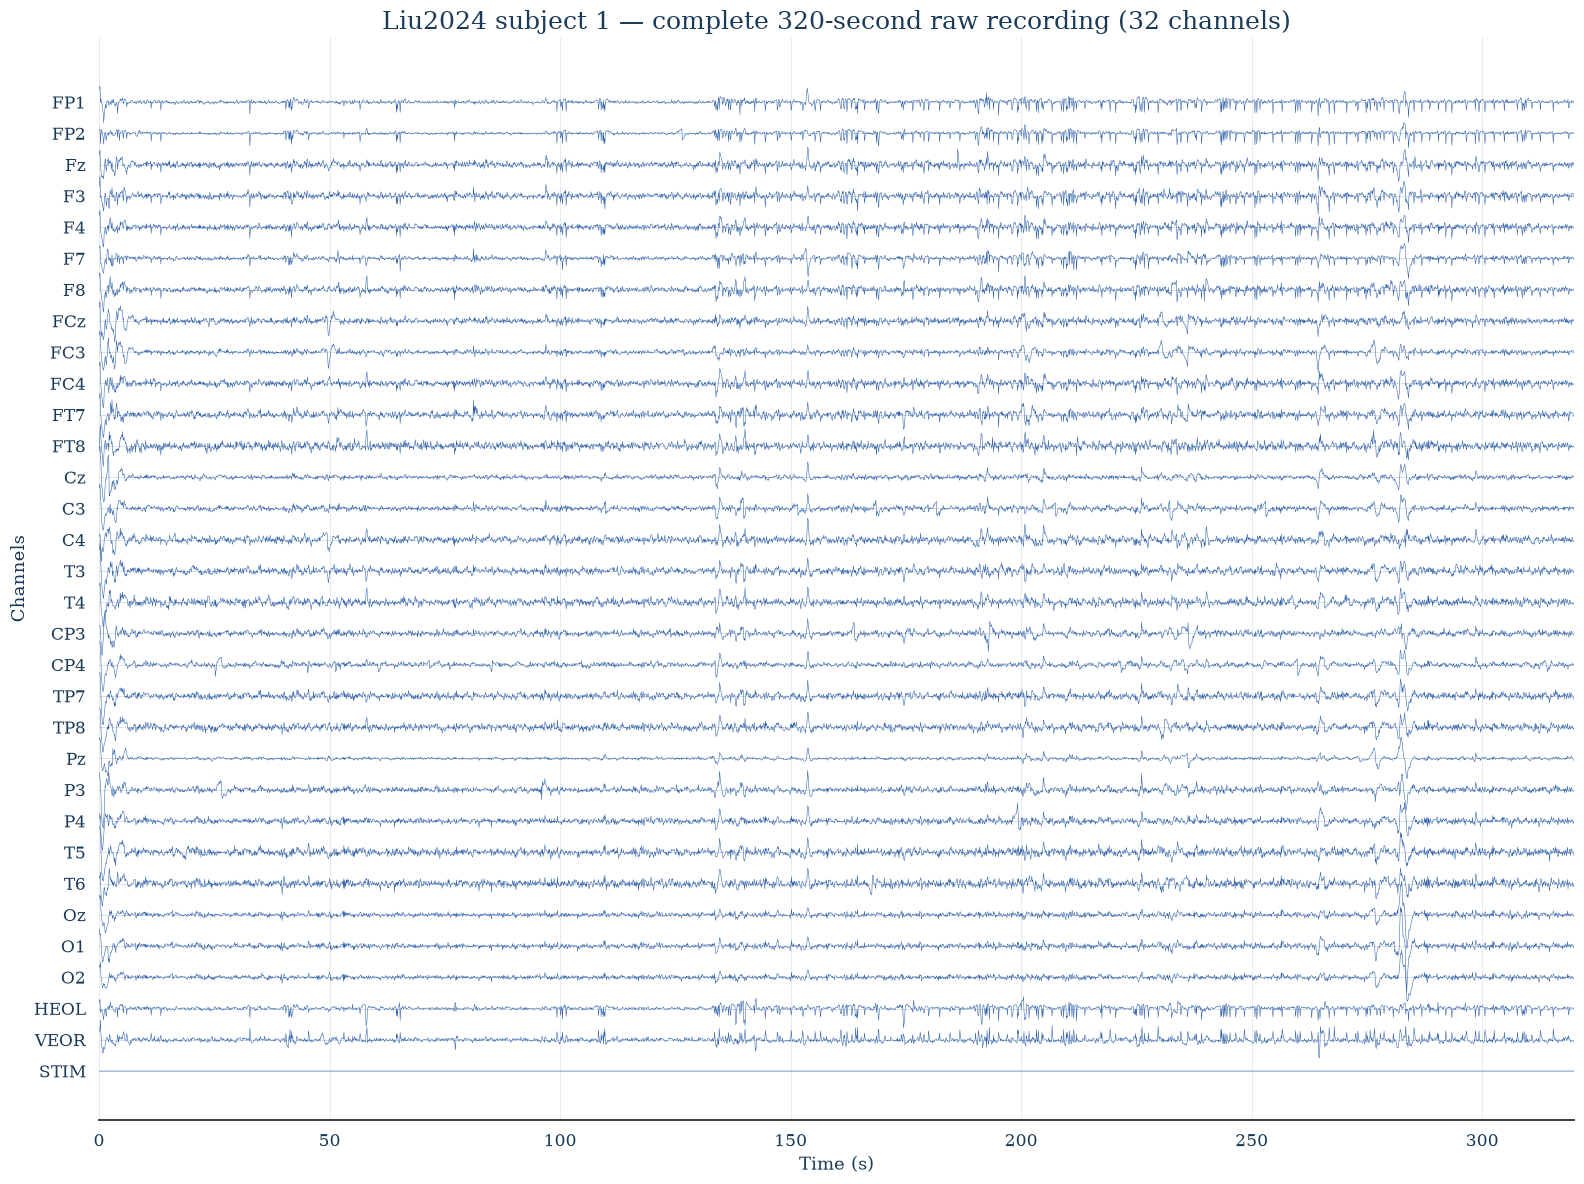

In [6]:
# Downsample only the displayed points so the complete recording remains readable.
display_step = max(1, int(raw.info["sfreq"] // 10))
display_data = raw.get_data()[:, ::display_step]
display_times = raw.times[::display_step]
display_scale = np.nanpercentile(np.abs(display_data), 99, axis=1, keepdims=True)
display_scale[display_scale == 0] = 1
display_traces = display_data / display_scale
channel_positions = np.arange(len(raw.ch_names))[::-1] * 3

fig, ax = plt.subplots(figsize=(16, 12))
ax.plot(display_times, (display_traces + channel_positions[:, None]).T, linewidth=0.35, color="#2457a6")
ax.set_yticks(channel_positions, raw.ch_names)
ax.set(xlim=(display_times[0], display_times[-1]), xlabel="Time (s)", ylabel="Channels", title=(f"Liu2024 subject {SUBJECT_IDS[0]} — complete {raw.times[-1]:.0f}-second raw recording ({len(raw.ch_names)} channels)"))
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()


## Standard Braindecode preprocessing

Keep EEG channels, apply a 4–38 Hz motor-imagery band-pass filter, resample from 500 Hz to 250 Hz, and perform exponential moving standardization. `preprocess` modifies the dataset in place.

In [7]:
TARGET_SFREQ = 250

preprocessors = [
    Preprocessor('pick', picks='eeg', apply_on_array=False),
    Preprocessor('filter', l_freq=4.0, h_freq=38.0, apply_on_array=False),
    Preprocessor('resample', sfreq=TARGET_SFREQ, apply_on_array=False),
    Preprocessor(
        exponential_moving_standardize,
        factor_new=1e-3,
        init_block_size=1000,
    ),
]

preprocess(dataset, preprocessors, n_jobs=1)
processed_raw = dataset.datasets[0].raw
print(processed_raw)
print('EEG channels:', len(processed_raw.ch_names))
print('Sampling frequency:', processed_raw.info['sfreq'], 'Hz')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 38 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 38.00 Hz
- Upper transition bandwidth: 9.50 Hz (-6 dB cutoff frequency: 42.75 Hz)
- Filter length: 825 samples (1.650 s)

<RawEDF | sub-01_task-motor-imagery_eeg.edf, 29 x 80000 (320.0 s), ~17.7 MiB, data loaded>
EEG channels: 29
Sampling frequency: 250.0 Hz


## Create trial windows from MOABB annotations

Liu2024 defines `left_hand` and `right_hand` events with a 0–4 second interval. Braindecode converts each annotation into one labeled training example.

In [8]:
windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=0,
    trial_stop_offset_samples=0,
    preload=True,
)

X, y, window_info = windows_dataset[0]
print('Number of trials:', len(windows_dataset))
print('One trial shape (channels, samples):', X.shape)
print('First target:', y, '(0=left hand, 1=right hand)')
print('Window indices [trial, start, stop]:', window_info)
display(windows_dataset.description)

Number of trials: 40
One trial shape (channels, samples): (29, 1000)
First target: 0 (0=left hand, 1=right hand)
Window indices [trial, start, stop]: [0, 501, 1501]


,subject,session,run
0,1,0,0


### Inspect the model features and target

`X` is one four-second trial after preprocessing. Rows are EEG channels, columns are time samples, and values are standardized (unitless). `y` is the integer action target.

In [9]:
TARGET_TO_ACTION = {value: key for key, value in ACTION_TO_TARGET.items()}
print("Feature array X:", X.shape, X.dtype)
print("Target y:", y, "=", TARGET_TO_ACTION[int(y)])
print("Sampling frequency:", processed_raw.info["sfreq"], "Hz")
print("Trial duration:", X.shape[1] / processed_raw.info["sfreq"], "seconds")

feature_preview = pd.DataFrame(
    X[:, :10],
    index=processed_raw.ch_names,
    columns=[f"sample_{index}" for index in range(10)],
)
feature_preview.index.name = "channel"
print("FIRST 10 STANDARDIZED FEATURE VALUES FOR EVERY EEG CHANNEL")
display(feature_preview)


Feature array X: (29, 1000) float32
Target y: 0 = left_hand
Sampling frequency: 250.0 Hz
Trial duration: 4.0 seconds
FIRST 10 STANDARDIZED FEATURE VALUES FOR EVERY EEG CHANNEL


,sample_0,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9
channel,,,,,,,,,,
FP1,0.104925,0.134676,0.169653,0.202684,0.209338,0.165222,0.069925,-0.042198,-0.116419,-0.110383
FP2,0.069138,0.061706,0.059939,0.077034,0.105244,0.121002,0.104323,0.056826,0.003582,-0.023169
Fz,0.058898,0.057625,0.052771,0.056862,0.070620,0.080677,0.070424,0.035657,-0.008168,-0.034287
F3,0.078008,0.085433,0.095464,0.105161,0.102983,0.073733,0.011159,-0.070405,-0.136772,-0.151027
F4,0.086708,0.066771,0.048534,0.061492,0.103042,0.137598,0.125443,0.058203,-0.028842,-0.079300
F7,-0.010231,0.005500,0.044039,0.081467,0.079640,0.012886,-0.108111,-0.233752,-0.299082,-0.259973
F8,0.139717,0.108249,0.082052,0.110690,0.183325,0.231394,0.186660,0.046384,-0.111782,-0.182211
FCz,0.023325,0.027488,0.027033,0.032056,0.045632,0.059917,0.061880,0.044505,0.014362,-0.011150
FC3,0.066481,0.075950,0.086890,0.097894,0.101457,0.086059,0.044781,-0.014839,-0.068955,-0.088731


## Standard PyTorch DataLoader

The resulting batches are ready for a Braindecode model such as EEGNet, ShallowFBCSPNet, or Deep4Net.

In [12]:
BATCH_SIZE = 16

train_loader = DataLoader(
    windows_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

X_batch, y_batch, window_info_batch = next(iter(train_loader))
print('Batch X shape:', tuple(X_batch.shape))
print('Batch y shape:', tuple(y_batch.shape))
print('Model parameters:')
print('  n_chans =', X_batch.shape[1])
print('  n_times =', X_batch.shape[2])
print('  n_outputs =', len(np.unique([windows_dataset[i][1] for i in range(len(windows_dataset))])))

Batch X shape: (16, 29, 1000)
Batch y shape: (16,)
Model parameters:
  n_chans = 29
  n_times = 1000
  n_outputs = 2
